# 予測市場

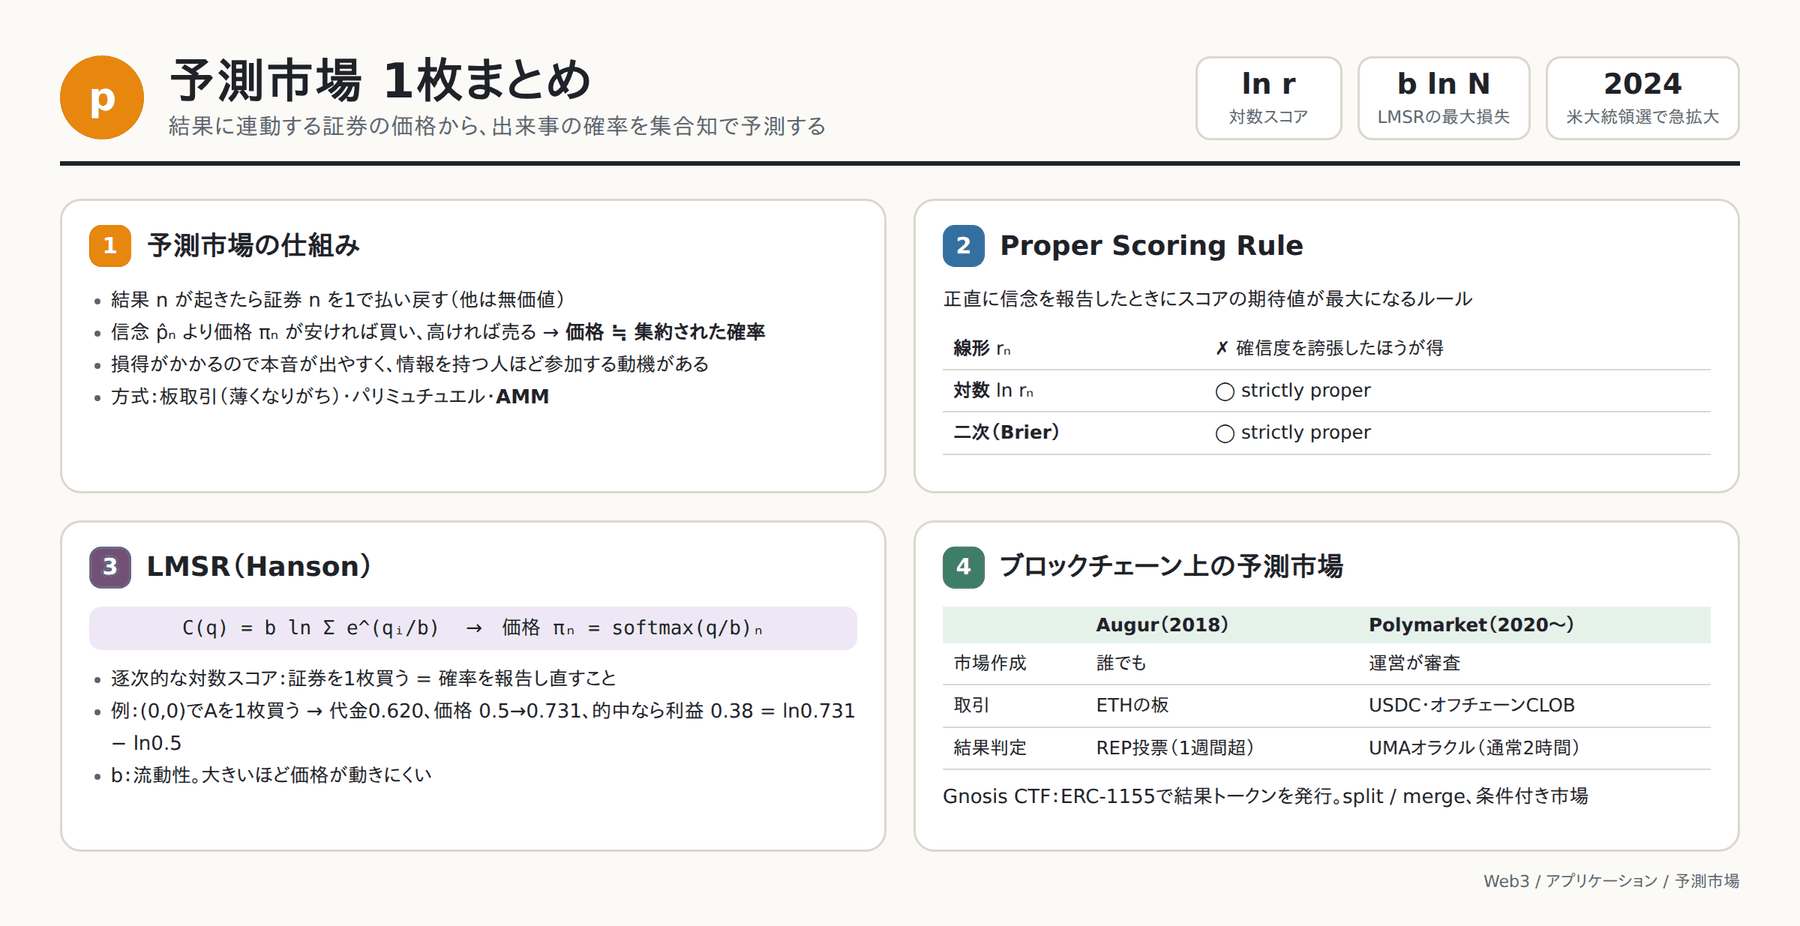

## 予測市場とは

**予測市場（prediction market）** は、将来の出来事の結果に応じて払い戻しが決まる証券を取引させ、その価格から出来事の確率を予測する仕組み。

確率変数 $\omega$ が標本空間 $\Omega = \{1, \dots, N\}$ の値をとるとき、その確率分布 $\boldsymbol{p} = (p_1, \dots, p_N)$ を知りたいとする。例えば「次の選挙で誰が当選するか」「来月の政策金利は上がるか」。

予測市場では、各結果 $n$ に対応する証券を発行し、

- 結果が $n$ になったら、証券 $n$ を1枚につき1（例えば1ドル）で払い戻す
- それ以外の証券は無価値になる

とする。リスク中立的な参加者は、自分の信念 $\hat{p}_n$ より証券の価格 $\pi_n$ が安ければ買い、高ければ売る。その結果、**市場価格は参加者たちの信念を集約したもの** になり、

$$
p_n \approx \frac{\pi_n}{\sum_i \pi_i}
$$

と予測できる。アンケートで直接確率を尋ねるのに比べ、

- 損得がかかっているので、参加者が本心と違う回答をしにくい
- 情報を持つ人ほど儲かるので、情報を持つ人が参加する動機がある

という利点がある。

:::{note}
参加者がリスク回避的だと、同じ信念でも価格は変わる。市場価格をそのまま集約された確率とみなせるかは、学術的にも論点が残っている。
:::

### 歴史

| 時期 | 出来事 |
| --- | --- |
| 1988〜 | アイオワ電子市場（Iowa Electronic Markets）。大学の研究目的で選挙の予測市場を運営 |
| 2001〜2003 | 米国防高等研究計画局（DARPA）のPolicy Analysis Market。テロや政変を賭けの対象にするとの批判で中止 |
| 2003〜2007 | Hansonによる LMSR の提案 |
| 2005〜2011 | Google、Yahoo!などで社内予測市場が盛んに試される |
| 2010年代 | 運営の難しさや賭博規制のリスクから下火に |
| 2014〜 | ブロックチェーン上で再興。Truthcoin（Hivemind）, Augur（2018）, Polymarket（2020） |
| 2024 | 米国大統領選挙でPolymarketの取引量が急増し、世論調査より正確だったと注目される |

## 取引の方式

予測市場の証券をどうやって売買させるかには、いくつかの方式がある。

| 方式 | 内容 | 課題 |
| --- | --- | --- |
| 連続ダブルオークション（板取引） | 買い注文と売り注文をマッチングする | 結果の選択肢が多く参加者が少ない予測市場では、板が薄くなりやすい |
| パリミュチュエル（競馬方式） | 賭け金を集め、当たった人で分け合う | 途中で売買できない。情報が価格に逐次反映されない |
| AMM（自動マーケットメーカー） | 運営者（またはコントラクト）が常に取引相手になり、価格を自動的に決める | 運営者が損失を負担する |

AMM方式の代表が **LMSR（Logarithmic Market Scoring Rule）** で、その基礎には **proper scoring rule** の理論がある。

## Proper Scoring Rule

後で答えが判明する問いについて、予測者に確率を報告させ、答えが出た時点で報告に応じたスコア（報酬）を与えるとする。**正直に自分の信念を報告したときに、スコアの期待値が最大になる** スコアリングルールを **proper scoring rule** と呼ぶ。

信念を $\hat{\boldsymbol{p}}$、報告を $\boldsymbol{r}$、結果が $n$ のときのスコアを $s_n(\boldsymbol{r})$ とすると、

$$
\sum_{n=1}^N \hat{p}_n s_n(\hat{\boldsymbol{p}}) \ge \sum_{n=1}^N \hat{p}_n s_n(\boldsymbol{r}) \quad (\forall \boldsymbol{r})
$$

が成り立つものがproper。等号が $\boldsymbol{r} = \hat{\boldsymbol{p}}$ のときだけ成り立つなら **strictly proper** という。

| ルール | スコア $s_n(\boldsymbol{r})$ | proper か |
| --- | --- | --- |
| 線形スコア | $r_n$ | properでない（確信度を誇張したほうが得） |
| 対数スコア（LSR） | $\ln r_n$ | strictly proper |
| 二次スコア（Brierスコア） | $2r_n - \sum_i r_i^2$ | strictly proper |

2択の場合、対数スコアの期待値 $\hat{p}\ln r + (1-\hat{p})\ln(1-r)$ を $r$ で微分して0とおくと

$$
\frac{\hat{p}}{r} = \frac{1-\hat{p}}{1-r} \iff r = \hat{p}
$$

となり、正直な報告が最適であることが分かる。

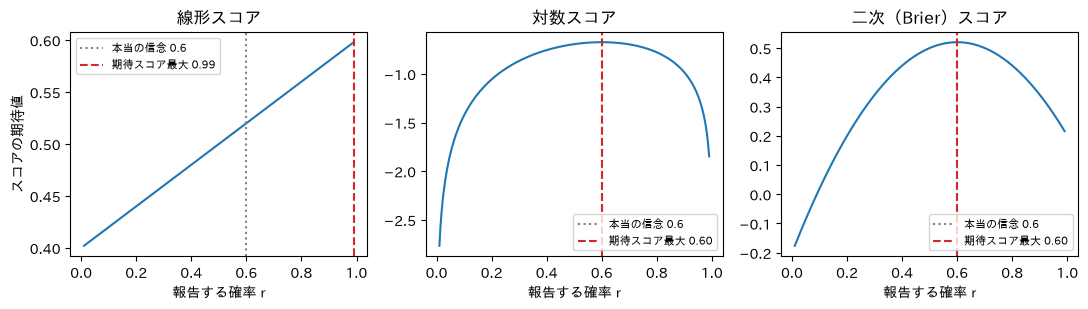

In [1]:
import matplotlib.pyplot as plt
import japanize_matplotlib  # noqa: F401
import numpy as np

p_belief = 0.6
r = np.linspace(0.01, 0.99, 500)
rules = {
    "線形": p_belief * r + (1 - p_belief) * (1 - r),
    "対数": p_belief * np.log(r) + (1 - p_belief) * np.log(1 - r),
    "二次（Brier）": p_belief * (2 * r - r**2 - (1 - r) ** 2) + (1 - p_belief) * (2 * (1 - r) - r**2 - (1 - r) ** 2),
}

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for ax, (name, score) in zip(axes, rules.items()):
    ax.plot(r, score)
    best = r[np.argmax(score)]
    ax.axvline(p_belief, color="gray", ls=":", label="本当の信念 0.6")
    ax.axvline(best, color="C3", ls="--", label=f"期待スコア最大 {best:.2f}")
    ax.set(title=f"{name}スコア", xlabel="報告する確率 r")
    ax.legend(fontsize=8)
axes[0].set_ylabel("スコアの期待値")
plt.tight_layout()
plt.show()

線形スコアでは、信念が0.6でも1を報告するのが最適になってしまう。対数スコアと二次スコアでは、正直に0.6と報告するのが最適になる。

## LMSR

**LMSR（Logarithmic Market Scoring Rule）** はHanson（2003, 2007）が提案した予測市場のAMM。対数スコアに次の2つの変更を加えたものと見なせる。

1. **スコアを逐次的にする**：各参加者は、直前の報告からの差分 $s_n(\boldsymbol{r}_{t}) - s_n(\boldsymbol{r}_{t-1})$ をスコアとして受け取る。前の人より良い予測をした人だけが得をする
2. **報告を証券の売買に置き換える**：確率を直接報告する代わりに、証券を売買すると価格（＝確率）が動く

### コスト関数

各証券の発行済み枚数を $\boldsymbol{q} = (q_1, \dots, q_N)$ として、コスト関数を

$$
C(\boldsymbol{q}) = b \ln \sum_{i=1}^N e^{q_i / b}
$$

と定める。$\boldsymbol{q}$ から $\boldsymbol{q}'$ に変える取引の代金は $C(\boldsymbol{q}') - C(\boldsymbol{q})$。各証券の瞬間的な価格は

$$
\pi_n = \frac{\partial C}{\partial q_n} = \frac{e^{q_n / b}}{\sum_i e^{q_i / b}}
$$

で、**ソフトマックス関数** になる。価格は常に正で合計が1なので、そのまま確率として解釈できる。

- $b$ は **流動性パラメーター**。大きいほど、同じ枚数の売買による価格の変化が小さい
- 運営者の最大損失は $b \ln N$ に抑えられる。初期状態（全確率 $1/N$）から、ある結果に確率1を付けられて、それが的中した場合が最悪で、そのとき運営者が払うスコアは $\ln 1 - \ln(1/N) = \ln N$ に $b$ を掛けたもの

In [2]:
def lmsr_cost(q, b=1.0):
    q = np.asarray(q, dtype=float)
    return b * np.log(np.exp(q / b).sum())


def lmsr_prices(q, b=1.0):
    e = np.exp(np.asarray(q, dtype=float) / b)
    return e / e.sum()


# 2択の市場（候補A, 候補B）。勝った側の証券に1を払い戻す
history = [
    ("初期状態", [0, 0]),
    ("Aを1枚買う", [1, 0]),
    ("Aを1枚買う", [2, 0]),
    ("Bを1枚買う", [2, 1]),
    ("Aを1枚売る", [1, 1]),
]
prev = None
print(f"{'取引':<10} {'q':<8} {'C(q)':>6} {'支払額':>7}   価格 (A, B)")
for label, q in history:
    c = lmsr_cost(q)
    pay = "" if prev is None else f"{c - prev:+.3f}"
    pa, pb = lmsr_prices(q)
    print(f"{label:<10} {str(q):<8} {c:6.3f} {pay:>7}   ({pa:.3f}, {pb:.3f})")
    prev = c

print(f"\n運営者の最大損失（b=1, N=2）: {np.log(2):.3f}")

取引         q          C(q)     支払額   価格 (A, B)
初期状態       [0, 0]    0.693           (0.500, 0.500)
Aを1枚買う     [1, 0]    1.313  +0.620   (0.731, 0.269)
Aを1枚買う     [2, 0]    2.127  +0.814   (0.881, 0.119)
Bを1枚買う     [2, 1]    2.313  +0.186   (0.731, 0.269)
Aを1枚売る     [1, 1]    1.693  -0.620   (0.500, 0.500)

運営者の最大損失（b=1, N=2）: 0.693


初期状態でAの証券を1枚買うと、代金は約0.620で、Aの価格（確率）は0.5から0.731に上がる。Aが勝てば1を受け取れるので、利益は約0.38。これは、対数スコアで確率の報告を0.5から0.731に更新したときのスコアの増分 $\ln 0.731 - \ln 0.5 \approx 0.38$ と一致する。つまり、**証券を1枚買うことは、確率を報告し直すことと同じ** になっている。

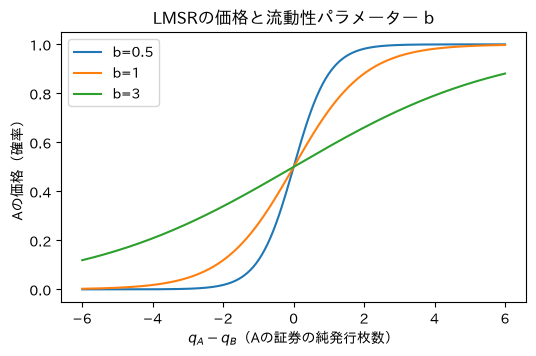

In [3]:
q_a = np.linspace(-6, 6, 300)
fig, ax = plt.subplots(figsize=(6, 3.5))
for b in [0.5, 1, 3]:
    ax.plot(q_a, [lmsr_prices([qa, 0], b)[0] for qa in q_a], label=f"b={b}")
ax.set(xlabel="$q_A - q_B$（Aの証券の純発行枚数）", ylabel="Aの価格（確率）", title="LMSRの価格と流動性パラメーター b")
ax.legend()
plt.show()

## ブロックチェーン上の予測市場

ブロックチェーンで予測市場を作る動機には、

- 運営者を介さず、取引の履歴や払い戻しを検証可能にできる
- 適切なインセンティブ設計があれば、運営コストを極めて小さくできる
- 「市場を通じて自律分散的に意見を集約する」という思想が、ブロックチェーンそのものと共通している

といったものがある。一方で、結果（現実の出来事）はチェーンの外の情報なので、**オラクル問題** が避けられない（→[オラクル](./defi/oracles.ipynb)）。

### Augur（2018年）

DAppsとしての分散型予測市場の元祖。自律分散性を徹底的に追求した。

- **市場の作成**：誰でも手数料とデポジットを払えば市場を作れる。作成者は取引手数料を得る
- **取引**：ETHによる板取引
- **結果の判定**：最初の報告者が結果を報告し、異議があればREPトークンの保有者が正しいと思う結果にREPを賭ける。多くのREPを集めた結果が採用され、外れた側のREPは正解側に分配される。決着がつかなければAugur自体がフォークする

しかし、

- 倫理的に問題のある市場（特定の人物の死亡を賭ける「暗殺市場」など）が作られた
- 板が薄く、ETHの価格変動とgas代が重荷になった
- 結果の確定までに1週間以上かかった

など、使い勝手の悪さからユーザーが増えず、開発は停滞した。

### Polymarket（2020年〜）

現在最もよく使われている予測市場。ある程度の自律分散性を犠牲にして、Augurの弱点を潰している。

| 項目 | Augur | Polymarket |
| --- | --- | --- |
| 市場の作成 | 誰でも | 運営者が審査して作成 |
| 取引の通貨 | ETH | USDC（ステーブルコイン） |
| 取引方式 | オンチェーンの板取引 | オフチェーンで注文をマッチングし、決済だけをオンチェーンで行うCLOB（中央指値注文板）。Polygon上で動作しgas代を削減 |
| 流動性の確保 | — | 中値付近に指値を出したマーケットメーカーに報酬を支払う |
| 結果の判定 | REPトークンによる投票 | UMAのオプティミスティックオラクル。報告から2時間異議がなければ確定、異議があればUMAトークン保有者の投票 |

これを妥協と見るか改善と見るかは議論が分かれる。

### Gnosis Conditional Token Framework

Gnosisは予測市場のための部品として、**Conditional Token Framework（CTF）** を提供している。

- 予測市場の証券（結果トークン）を、1つのERC-1155コントラクトで発行・管理する。市場ごとにコントラクトをデプロイする必要がない
- 1 USDCを預けると、全結果のトークンを1枚ずつ受け取れる（split）。全結果のトークンを1枚ずつ揃えれば1 USDCに戻せる（merge）
- 「Aが予備選で勝ち、かつ本選でも勝つ」のような **条件付きの結果** も、トークンを階層的にsplitして表現できる

PolymarketもCTFで結果トークンを発行している。一方、CTFが用意したAMM（LMSR、CPAMM）はあまり使われていない。LMSRは指数・対数の計算でgas代がかさみ、CPAMMは結果ごとにプールが分かれて流動性が集まりにくいためである。

## 参考文献

- 水山元 (2014). [予測市場とその周辺](https://www.jstage.jst.go.jp/article/jjsai/29/1/29_34/_pdf/-char/ja). 人工知能, 29(1), 34-40.
- Hanson, R. (2003). Combinatorial Information Market Design. *Information Systems Frontiers*, 5, 107-119.
- Hanson, R. (2007). Logarithmic Market Scoring Rules for Modular Combinatorial Information Aggregation. *The Journal of Prediction Markets*, 1(1), 3-15.
- Chen, Y. & Pennock, D. M. (2010). Designing Markets for Prediction. *AI Magazine*, 31(4), 42-52.
- Wolfers, J. & Zitzewitz, E. (2004). Prediction Markets. *Journal of Economic Perspectives*, 18(2), 107-126.
- Peterson, J. et al. (2015). [Augur: a Decentralized Oracle and Prediction Market Platform](https://github.com/AugurProject/whitepaper).
- [Polymarket Documentation](https://docs.polymarket.com/)